In [1]:
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
import shutil

from astropy.nddata import CCDData
from astropy.stats import SigmaClip, mad_std
from astropy import units as u
from astropy.table import QTable
from astropy.io import fits
from astropy.wcs import WCS

import ccdproc as ccdp

import sep

matplotlib.rcParams.update({'font.size': 12})

%matplotlib inline

### Locate all images

In [2]:
read_path = '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/solve/'
wcs_dir = '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/solve/'
img_table_solved = QTable.read(read_path + 'tabulated_solved.fits')

In [3]:
default_gain = abs(img_table_solved['GAINFACT'] - 4.0) < 1e-3
default_exp = abs(img_table_solved['EXPTIME'] - 0.1 * u.s) < 1e-3 * u.s
solved = img_table_solved['SOLVED'] > 0
daytime_float = []
for fname in img_table_solved['FILES']:
    if (
        ('10-01_18' in fname)
        or ('10-01_19' in fname)
        or ('10-01_20' in fname)
        or ('10-01_21' in fname)
        or ('10-01_22' in fname)
        or ('10-01_23' in fname)
        or ('10-02_00' in fname)
    ):
        daytime_float.append(True)
        # print(fname)
    else:
        daytime_float.append(False)
daytime_float = np.array(daytime_float)
candidates = (default_gain & default_exp & daytime_float & solved)

In [4]:
# reduced data path
direc = '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/'
calibrated_data = Path(direc)
calibrated_data.mkdir(exist_ok=True)

In [5]:
img_table_solved[candidates]

FOCUSMIN,FOCUS,FOCUSMAX,GAINFACT,EXPTIME,UTC-SEC,UTC-USEC,CCDTEMP,FILES,SOLVE_ATTEMPTED,SOLVED,FILESIZE,TIMESTAMP,RA,DEC,ORIENTATION,SCALE,N_STARS_FOUND,N_STARS_MATCHED,RMSE,BKG_MED,BKG_MEAN
,,,,s,s,s,deg_C,,,,,s,deg,deg,deg,arcsec / pix,,,arcsec,,
float64,float64,float64,float64,float64,float64,float64,float64,bytes57,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64
-7487.0,-12.0,409.0,4.0,0.1000048,1759343393.0,0.965135,20.3125,/media/shared/img/saved_image_2025-10-01_18-29-54.fits.fz,1.0,1.0,15713280.0,1759343393.965135,242.96963167298932,46.77527632764416,92.12400513931891,6.80154,14.0,14.0,3.7138430904833966,nan,636.720458984375
-7487.0,-12.0,409.0,4.0,0.1000048,1759343395.0,0.46981799999999996,20.3125,/media/shared/img/saved_image_2025-10-01_18-29-55.fits.fz,1.0,1.0,16706880.0,1759343395.469818,242.9635978224276,46.77953682431544,92.11555840998813,6.8003,17.0,16.0,2.786394108866321,nan,1276.24462890625
-7487.0,-12.0,409.0,4.0,0.1000048,1759343396.0,0.9776889999999999,20.3125,/media/shared/img/saved_image_2025-10-01_18-29-57.fits.fz,1.0,1.0,16706880.0,1759343396.977689,242.97594850138682,46.7867684824497,92.10496644424686,6.80111,18.0,18.0,3.077879075793777,nan,1276.811279296875
-7487.0,-12.0,409.0,4.0,0.1000048,1759343398.0,0.48173699999999997,20.3125,/media/shared/img/saved_image_2025-10-01_18-29-58.fits.fz,1.0,1.0,16706880.0,1759343398.481737,243.00547245628584,46.799119254758295,92.08237885297494,6.80022,21.0,19.0,3.4500529220379876,nan,1276.8154296875
-7487.0,-12.0,409.0,4.0,0.1000048,1759343399.0,0.995042,20.3125,/media/shared/img/saved_image_2025-10-01_18-30-00.fits.fz,1.0,1.0,16706880.0,1759343399.995042,243.04768363996243,46.825131912036824,92.06787201023673,6.80029,18.0,17.0,3.431129984091234,nan,1276.961181640625
-7487.0,-12.0,409.0,4.0,0.1000048,1759343401.0,0.499978,20.3125,/media/shared/img/saved_image_2025-10-01_18-30-01.fits.fz,1.0,1.0,16706880.0,1759343401.499978,243.10089199413738,46.85487204198566,92.03614912082708,6.80099,22.0,20.0,3.440169779313061,nan,1277.29296875
-7487.0,-12.0,409.0,4.0,0.1000048,1759343403.0,0.00859,20.3125,/media/shared/img/saved_image_2025-10-01_18-30-03.fits.fz,1.0,1.0,16706880.0,1759343403.00859,243.1666844763518,46.900839380044374,92.00130287760079,6.80142,24.0,21.0,3.193499276549239,nan,1277.181396484375
-7487.0,-12.0,409.0,4.0,0.1000048,1759343404.0,0.516733,20.3125,/media/shared/img/saved_image_2025-10-01_18-30-04.fits.fz,1.0,1.0,16706880.0,1759343404.516733,243.23119298163246,46.97298191857449,91.94952499014164,6.80165,22.0,18.0,3.338917636634959,nan,1277.7225341796875


After an autofocus, one frame is captured with AF settings, and should not be considered. Exclude them on grounds of difference in file size (noise level).

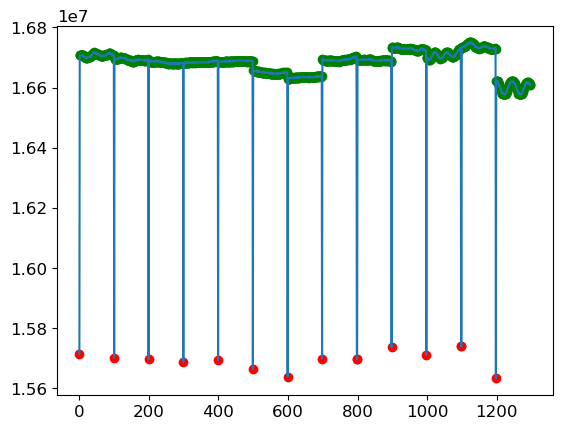

In [6]:
bkg_mean = img_table_solved[candidates]['FILESIZE']
mu, sig = np.mean(bkg_mean), np.std(bkg_mean)
condition = np.abs(bkg_mean - mu) > 3*sig
outliers = np.where(condition)[0]
inliers = np.where(~condition)[0]
plt.figure()
plt.plot(img_table_solved[candidates]['FILESIZE'])
plt.scatter(np.arange(len(img_table_solved[candidates]))[outliers], img_table_solved[candidates][outliers]['FILESIZE'], color='r')
plt.scatter(np.arange(len(img_table_solved[candidates]))[inliers], img_table_solved[candidates][inliers]['FILESIZE'], color='g')
plt.show()

In [7]:
good_files = img_table_solved[candidates][inliers]['FILES']
good_basenames = [os.path.basename(f) for f in good_files]

In [15]:
remote_path = '/media/shared/img'
local_path = '/media/shared/tim/TIMcam/img'

sci_files = ccdp.ImageFileCollection(filenames=[str(item).replace(remote_path, local_path) for item in img_table_solved[candidates][inliers]['FILES']][::50])
dark_files = ccdp.ImageFileCollection('/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_4/exptime_100/', glob_include=f'*.fits.fz')
bias_files = ccdp.ImageFileCollection('/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/bias/gain_4/exptime_0.01689/', glob_include=f'*.fits.fz')
flat_files = ccdp.ImageFileCollection('/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/flat/gain_4/exptime_6/', glob_include=f'*.fits.fz')

In [16]:
processing_steps = {
    'sci': len(sci_files.files) > 0,
    'dark': len(dark_files.files) > 0,
    'flat': len(flat_files.files) > 0,
    'bias': len(bias_files.files) > 0,
}

print(processing_steps)
print(sci_files.files)
print(dark_files.files)
print(bias_files.files)
print(flat_files.files)

{'sci': True, 'dark': True, 'flat': True, 'bias': True}
['/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-29-55.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-31-10.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_18-59-58.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_19-01-13.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_19-32-10.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_19-33-25.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_20-02-13.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_20-03-28.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_20-32-14.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_20-33-29.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_21-02-15.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_21-03-30.fits.fz', '/media/shared/tim/TIMcam/img/saved_image_2025-10-01_21-32-17.fits.fz', '/media

### Calibrate and combine bias images

Method: sigma-clipped median

INFO:astropy:splitting each image into 23 chunks to limit memory usage to 4000000000.0 bytes.


INFO: splitting each image into 23 chunks to limit memory usage to 4000000000.0 bytes. [ccdproc.combiner]


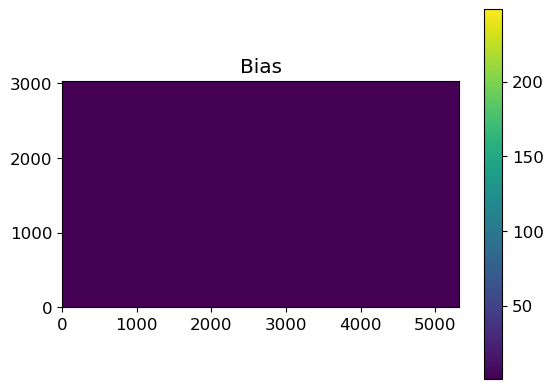

In [10]:
# no overscan: no calibration to be done to bias images before combination & subtraction
if processing_steps['bias']:
    if not os.path.exists(os.path.join(calibrated_data, 'bias')):
        os.makedirs(os.path.join(calibrated_data, 'bias'))
    for bias in bias_files.files:
        shutil.copy(os.path.join(bias_files.location, bias), os.path.join(calibrated_data, 'bias'))
    # print(os.listdir(os.path.join(calibrated_data, 'bias')))

    calibrated_biases = ccdp.ImageFileCollection(calibrated_data / 'bias', glob_include='*.fits.fz')
    if calibrated_biases.files:
        combined_bias = ccdp.combine(
            [os.path.join(calibrated_biases.location, file) for file in calibrated_biases.files],
            method='average',
            sigma_clip=True,
            sigma_clip_low_thresh=5,
            sigma_clip_high_thresh=5,
            sigma_clip_func=np.ma.median,
            sigma_clip_dev_func=mad_std,
            mem_limit=4e9,
            hdu=1
        )
        combined_bias.meta['combined'] = True
        combined_bias.write(calibrated_data / 'bias' / 'combined_bias.fits', overwrite=True)

        if True:
            fig, ax = plt.subplots()
            im = ax.imshow(
                combined_bias.data,
                origin='lower',
            )
            plt.colorbar(im)
            ax.set_title("Bias")
            plt.show()

### Combine dark images

Method: sigma-clipped median

In [11]:
if processing_steps['dark']:
    if not os.path.exists(os.path.join(calibrated_data, 'dark')):
        os.makedirs(os.path.join(calibrated_data, 'dark'))

    dark_paths = [os.path.join(dark_files.location, file) for file in dark_files.files]
    print('combining dark files', dark_paths)
    combined_dark = ccdp.combine(
        dark_paths,
        output_file=os.path.join(calibrated_data, 'dark', 'combined_dark.fits'),
        overwrite_output=True,
        method='average',
        sigma_clip=True,
        sigma_clip_low_thresh=5,
        sigma_clip_high_thresh=5,
        sigma_clip_func=np.ma.median,
        sigma_clip_dev_func=mad_std,
        mem_limit=4e9,
        hdu=1
    )

    vis = True
    # Combine dark frames
    combined_dark_frame = CCDData.read(calibrated_data / 'dark' / 'combined_dark.fits')
    if vis:
        fig, ax = plt.subplots()
        ax.imshow(
            combined_dark_frame.data,
            vmin=-.4*combined_dark_frame.data.std() + np.median(combined_dark_frame.data),
            vmax=.4*combined_dark_frame.data.std() + np.median(combined_dark_frame.data)
        )
        ax.set_title('Combined dark frame')

combining dark files ['/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_4/exptime_100/saved_image_2025-09-03_21-48-57.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_4/exptime_100/saved_image_2025-09-03_21-48-59.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_4/exptime_100/saved_image_2025-09-03_21-49-00.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_4/exptime_100/saved_image_2025-09-03_21-49-01.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_4/exptime_100/saved_image_2025-09-03_21-49-03.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_4/exptime_100/saved_image_2025-09-03_21-49-04.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/ground_test/20250903_timcam_cal/dark/gain_4/exptime_100/saved_image_2025-09

INFO:astropy:splitting each image into 4 chunks to limit memory usage to 4000000000.0 bytes.


INFO: splitting each image into 4 chunks to limit memory usage to 4000000000.0 bytes. [ccdproc.combiner]


### Flat-field correction

Use flats to derive a flat-field correction.

In [12]:
# https://www.astropy.org/ccd-reduction-and-photometry-guide/v/dev/notebooks/05-04-Combining-flats.html

def inv_median(a):
    return 1 / np.median(a)

In [13]:
def true_flatfield(calibrated_data, flat_files, combined_bias, combined_dark):
    # First, subtract off dark + bias from flat frames.
    for i, flat in enumerate(flat_files.files):
        # subtract dark current and bias noise in one step
        flat_raw = CCDData.read(os.path.join(flat_files.location, flat), hdu=1)
        # flat_raw = CCDData.read(flat)
        reduced = ccdp.subtract_bias(
            flat_raw,
            combined_bias,
        )
        # reduced = ccdp.subtract_dark(
        #     reduced,
        #     combined_dark,
            # exposure_time='exptime',
            # exposure_unit=u.second
        # )
        reduced.write(calibrated_data / 'flat' / flat, format='fits', overwrite=True)
    # Combine flat frames
    if not os.path.exists(os.path.join(calibrated_data, 'flat')):
        os.makedirs(os.path.join(calibrated_data, 'flat'))
    print([os.path.join(calibrated_data, 'flat', file) for file in flat_files.files])
    combined_flat = ccdp.combine([os.path.join(calibrated_data, 'flat', file) for file in flat_files.files],
        output_file=os.path.join(calibrated_data, 'flat', 'combined_flat.fits'),
        overwrite_output=True,
        method='average',
        scale=inv_median,
        sigma_clip=True,
        sigma_clip_low_thresh=5,
        sigma_clip_high_thresh=5,
        sigma_clip_func=np.ma.median,
        signma_clip_dev_func=mad_std,
        mem_limit=4e9,
    )

    flat_data = combined_flat.data
    return flat_data


def sep_flatfield(img):
    z = img.astype(np.float64)
    opts = dict(
        # bw=78,
        # bh=78,
        # fw=16,
        # fh=16
    )
    flat_data = sep.Background(z, **opts)
    return flat_data

In [17]:
# Combine flat field data
vis = True

combined_bias = ccdp.CCDData.read(calibrated_data / 'bias' / 'combined_bias.fits')
combined_dark = ccdp.CCDData.read(calibrated_data / 'dark' / 'combined_dark.fits')

flat_data = true_flatfield(calibrated_data, flat_files, combined_bias, combined_dark)

['/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-58-57.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-58-58.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-59-00.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-59-01.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-59-03.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-59-04.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-59-06.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-59-07.fits.fz', '/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/flat/saved_image_2025-09-03_21-59-09.fits.fz', '/home/evanmayer/TIM_data/t

INFO:astropy:splitting each image into 3 chunks to limit memory usage to 4000000000.0 bytes.


INFO: splitting each image into 3 chunks to limit memory usage to 4000000000.0 bytes. [ccdproc.combiner]


0.9999999999999999


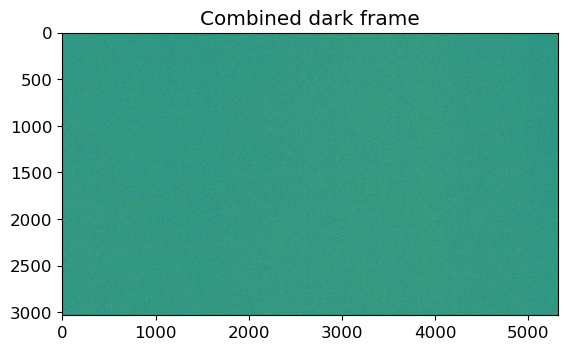

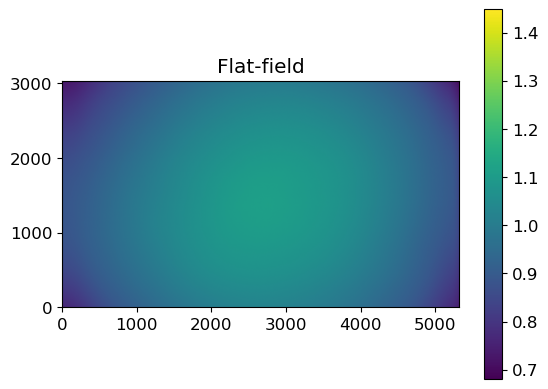

In [18]:
# scale derived flat by the median
# flat_data -= np.min(flat_data)
flat_data /= np.median(flat_data)
flat_data[flat_data < 1e-9] = np.median(flat_data)
print(np.median(flat_data))
combined_flat = CCDData(flat_data, unit='adu')

combined_flat.write(calibrated_data / 'flat' / 'scaled_flat.fits', format='fits', overwrite=True)

if vis:
    fig, ax = plt.subplots()
    im = ax.imshow(
        flat_data,
        origin='lower',
    )
    plt.colorbar(im)
    ax.set_title("Flat-field")
    plt.show()

### Finally, subtract median - (dark + bias) data, and divide out flat-field.

* Apply gain correction to convert ADU to e-
* Divide by exposure time to get e-/s
* Look up WCS solution from preprocessing and apply to the file

Save off corrected frames in the reduced data directory.

In [19]:
def calibrate(file):
    sci = file
    # subtract dark current and bias noise in one step
    sci_raw = CCDData.read(sci, hdu=1)
    combined_dark = ccdp.CCDData.read(calibrated_data / 'dark' / 'combined_dark.fits')
    reduced = ccdp.subtract_dark(
        sci_raw,
        combined_dark,
        exposure_time='EXPTIME',
        exposure_unit=u.second,
    )

    # divide out flat field
    combined_flat = ccdp.CCDData.read(calibrated_data / 'flat' / 'scaled_flat.fits')
    reduced = ccdp.flat_correct(reduced, combined_flat)

    # convert to electrons/s from ADUs
    # https://thinklucid.com/product/triton-16-2-mp-imx542/?srsltid=AfmBOorWeS_UYDtT8ZuoNhhgyEVhc7NRxoBQiFOYLiM8PHZ1PaTqk6eL
    # base_gain = 0.42 # DN/e-, also broadly consistent with N grey levels / full well e-
    base_gain = (1. / 2.310791016)
    gainfact = reduced.header['GAINFACT']
    total_gain_e_per_adu = (1. / (base_gain * gainfact)) * u.electron / u.adu / u.s
    reduced = ccdp.gain_correct(reduced, total_gain_e_per_adu)
    exptime = reduced.header['EXPTIME']
    reduced.data /= exptime

    # for storage
    reduced.data = reduced.data.astype(np.uint16)

    # try to use cached plate solve from initial data processing
    wcs_file = os.path.basename(sci).replace('.fits.fz', '_funpack.wcs')
    if os.path.exists(wcs_dir + wcs_file):
        with fits.open(wcs_dir + wcs_file) as f:
            h = f[0].header
        wcs = WCS(header=h)
        reduced.wcs = wcs
    # merge_wcs(calibrated_data / 'sci' / sci, wcs)

    # save reduced file
    # print('Successfully reduced', sci, ', saving to', calibrated_data / 'sci' / os.path.basename(sci), end='\r')
    print(f'{list(sci_files.files).index(sci) / len(sci_files.files):.3f}')
    # for storage, throw away mask and uncert HDUs
    reduced.to_hdu()[0].writeto(calibrated_data / 'sci' / os.path.basename(sci), overwrite=True)

In [20]:
from multiprocessing import Pool

with Pool(6) as p:
    p.map(calibrate, sci_files.files)

0.154


0.231


0.000


0.308


0.385


0.077
0.192
0.269
0.346
0.038
0.423
0.115
0.462
0.538
0.615
0.692
0.769
0.846
0.500
0.577
0.654
0.808
0.731
0.885
0.923
0.962


In [ ]:
sci_cal = ccdp.ImageFileCollection('/home/evanmayer/TIM_data/test_events/TIMcam/flight_test/cal/sci/', glob_include=f'*.fits.fz')
print(len(sci_cal.files))